# 04 — GraphSAGE para Predição de Links

Terceira família de modelos do projeto. Treina um **GraphSAGE** (Hamilton et al., 2017) sobre o subgrafo de mensagem `grafo_treino_msg.graphml` e usa o produto de Hadamard dos embeddings finais para pontuar pares de nós.

Detalhes de design, justificativas e hiperparâmetros: `spec/gnn.md` e `docs/07_gnn.md`.

## Pipeline

| Etapa | O que faz |
|---|---|
| 1. Features de nó | Lê `autores_grafo_treino.csv` (corte 2018-2023). Constrói a matriz `X` (N × D) com 5 features numéricas. `citation_count` recebe `log1p` antes do `StandardScaler`; demais usam `StandardScaler` direto. |
| 2. Grafo de mensagem | Lê `grafo_treino_msg.graphml` (90% das arestas de treino) como `edge_index`. `local_degree` é calculado nesse subgrafo. |
| 3. Splits | Reutiliza `train_pairs.csv` (10% holdout + negativos), `val_pairs.csv`, `test_pairs.csv` — mesmos pares das fases anteriores. |
| 4. Modelo | `SAGEConv(D, 256) → ReLU → Dropout → SAGEConv(256, 128) → ReLU → Dropout → Hadamard → MLP(128 → 64 → 1)`. |
| 5. Treino | `BCEWithLogitsLoss`, `Adam(lr=1e-3, weight_decay=5e-4)`, dropout 0.3, early stopping (paciência 20) por AUC-ROC em validação. |
| 6. Avaliação | Val + teste com AUC-ROC, Average Precision e F1. Consolida resultado em `data/results/gnn/results.csv`. |

## 1. Setup

In [1]:
# !pip install torch torch_geometric

In [2]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    roc_curve, auc,
)

AUTHORS_CSV  = Path("../data/processed/autores_grafo_treino.csv")
GRAPH_PATH   = Path("../data/graphs/grafo_treino_msg.graphml")
SPLITS_DIR   = Path("../data/splits")
RESULTS_DIR  = Path("../data/results/gnn")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

YEAR_CUTOFF  = 2023
INCLUDE_AREAS = False  # True na rodada de ablação (multi-hot de áreas)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

/home/lipecorradini/anaconda3/lib/python3.9/site-packages/torch/__config__.py:9: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._show_config()
/home/lipecorradini/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Device: cpu


## 2. Carregamento de dados

- **Autores**: atributos já com corte 2018-2023 (`spec/features_temporal_cutoff.md`).
- **Grafo de mensagem**: 90% das arestas de treino. Os 10% restantes vivem em `train_pairs.csv` como positivos de supervisão (`spec/message_supervision_split.md`).
- **Splits**: mesmos arquivos de pares usados em heurísticas e ML clássico, garantindo comparação direta.

In [3]:
autores = pd.read_csv(AUTHORS_CSV)
autores["auth_id"] = autores["auth_id"].astype(str)

G_train_msg = nx.read_graphml(GRAPH_PATH)

train_df = pd.read_csv(SPLITS_DIR / "train_pairs.csv")
val_df   = pd.read_csv(SPLITS_DIR / "val_pairs.csv")
test_df  = pd.read_csv(SPLITS_DIR / "test_pairs.csv")

for df in (train_df, val_df, test_df):
    df["node_u"] = df["node_u"].astype(str)
    df["node_v"] = df["node_v"].astype(str)

print(f"Autores                 : {len(autores)}")
print(f"Grafo de mensagem       : {G_train_msg.number_of_nodes()} nós, {G_train_msg.number_of_edges()} arestas")
print(f"Treino  pares           : {len(train_df):>6}  (pos {int(train_df['label'].sum()):>5} / neg {int((train_df['label']==0).sum()):>5})")
print(f"Val     pares           : {len(val_df):>6}  (pos {int(val_df['label'].sum()):>5} / neg {int((val_df['label']==0).sum()):>5})")
print(f"Teste   pares           : {len(test_df):>6}  (pos {int(test_df['label'].sum()):>5} / neg {int((test_df['label']==0).sum()):>5})")

Autores                 : 9154
Grafo de mensagem       : 9089 nós, 51961 arestas
Treino  pares           :  11548  (pos  5774 / neg  5774)
Val     pares           :   6284  (pos  3142 / neg  3142)
Teste   pares           :   4846  (pos  2423 / neg  2423)


## 3. Mapeamento nó → índice

PyG identifica nós por inteiros contiguos `[0, N)`. O universo de nós é a união dos nós do grafo de mensagem com qualquer nó referenciado nos splits, para garantir que toda aresta tenha sua linha em `X`.

In [4]:
node_ids = set(G_train_msg.nodes())
for df in (train_df, val_df, test_df):
    node_ids.update(df["node_u"].tolist())
    node_ids.update(df["node_v"].tolist())

node_list = sorted(node_ids, key=lambda x: int(x))
id_to_idx = {n: i for i, n in enumerate(node_list)}
N = len(node_list)

missing_in_authors = sum(1 for n in node_list if n not in set(autores["auth_id"]))
print(f"Total de nós              : {N}")
print(f"Nós sem entrada no CSV de autores: {missing_in_authors}")

Total de nós              : 9154
Nós sem entrada no CSV de autores: 0


## 4. Matriz de features de nó

Cinco features numéricas conforme `spec/gnn.md` seção 2.1:

| Feature | Fonte | Pré-processamento |
|---|---|---|
| `citation_count` | `autores_grafo_treino.csv` | `log1p` → `StandardScaler` |
| `document_count` | `autores_grafo_treino.csv` | `StandardScaler` |
| `h_index`        | `autores_grafo_treino.csv` | `StandardScaler` |
| `academic_age`   | `2023 - pub_year_first`    | `StandardScaler` |
| `local_degree`   | grau no grafo de mensagem  | `StandardScaler` |

Nós sem entrada no CSV recebem 0 antes da normalização (atributo ausente → "mediano" no espaço padronizado).

In [5]:
attr = autores.set_index("auth_id").reindex(node_list)

citation_count = attr["citation_count"].fillna(0).to_numpy(dtype=float)
document_count = attr["document_count"].fillna(0).to_numpy(dtype=float)
h_index        = attr["h_index"].fillna(0).to_numpy(dtype=float)
academic_age   = (YEAR_CUTOFF - attr["pub_year_first"].fillna(YEAR_CUTOFF)).to_numpy(dtype=float)

degree_map = dict(G_train_msg.degree())
local_degree = np.array([degree_map.get(n, 0) for n in node_list], dtype=float)

citation_count = np.log1p(citation_count)

X_numeric = np.column_stack([
    citation_count,
    document_count,
    h_index,
    academic_age,
    local_degree,
])

scaler = StandardScaler()
X_numeric = scaler.fit_transform(X_numeric)

print(f"X_numeric: {X_numeric.shape}")
print(f"  média por coluna  : {X_numeric.mean(axis=0).round(3)}")
print(f"  desvio por coluna : {X_numeric.std(axis=0).round(3)}")

X_numeric: (9154, 5)
  média por coluna  : [ 0.  0. -0.  0. -0.]
  desvio por coluna : [1. 1. 1. 1. 1.]


In [6]:
if INCLUDE_AREAS:
    from sklearn.preprocessing import MultiLabelBinarizer
    train_node_set = set(G_train_msg.nodes())
    areas_train = (
        autores[autores["auth_id"].isin(train_node_set)]["areas"]
        .fillna("").str.split(";")
        .apply(lambda lst: [a.strip() for a in lst if a.strip()])
    )
    mlb = MultiLabelBinarizer()
    mlb.fit(areas_train)

    areas_all = (
        attr["areas"].fillna("").str.split(";")
        .apply(lambda lst: [a.strip() for a in lst if a.strip()])
    )
    areas_matrix = mlb.transform(areas_all).astype(float)
    X = np.hstack([X_numeric, areas_matrix])
    print(f"X (com áreas): {X.shape}  | n_areas = {areas_matrix.shape[1]}")
else:
    X = X_numeric
    print(f"X (sem áreas): {X.shape}")

x_tensor = torch.tensor(X, dtype=torch.float)

X (sem áreas): (9154, 5)


## 5. `edge_index` do grafo de mensagem

Grafo não-direcionado → cada aresta vira duas entradas (`u→v` e `v→u`) para o message-passing do GraphSAGE propagar nas duas direções.

In [7]:
src, dst = [], []
for u, v in G_train_msg.edges():
    iu, iv = id_to_idx[u], id_to_idx[v]
    src.append(iu); dst.append(iv)
    src.append(iv); dst.append(iu)

edge_index = torch.tensor([src, dst], dtype=torch.long)

data = Data(x=x_tensor, edge_index=edge_index).to(device)
print(f"PyG Data: {data}")

PyG Data: Data(x=[9154, 5], edge_index=[2, 103922])


## 6. Pares de supervisão

Converte os splits em tensores `(2, n_pairs)` + rótulos. Os mesmos arquivos de heurísticas/ML clássico são reutilizados.

In [8]:
def df_to_tensors(df):
    u = df["node_u"].map(id_to_idx).to_numpy()
    v = df["node_v"].map(id_to_idx).to_numpy()
    pairs  = torch.tensor(np.stack([u, v]), dtype=torch.long).to(device)
    labels = torch.tensor(df["label"].to_numpy(), dtype=torch.float).to(device)
    return pairs, labels

train_pairs, train_y = df_to_tensors(train_df)
val_pairs,   val_y   = df_to_tensors(val_df)
test_pairs,  test_y  = df_to_tensors(test_df)

print(f"train_pairs: {tuple(train_pairs.shape)}  |  val_pairs: {tuple(val_pairs.shape)}  |  test_pairs: {tuple(test_pairs.shape)}")

train_pairs: (2, 11548)  |  val_pairs: (2, 6284)  |  test_pairs: (2, 4846)


## 7. Modelo: GraphSAGE + MLP de score

Arquitetura conforme `spec/gnn.md` seção 5.2:

```
X → SAGEConv(D_in, 256) → ReLU → Dropout(0.3)
  → SAGEConv(256, 128)  → ReLU → Dropout(0.3)
  → [h_u ⊙ h_v]
  → Linear(128, 64) → ReLU
  → Linear(64, 1)  (logit)
```

Produto de Hadamard mantém a simetria do grafo não-direcionado: `score(u, v) = score(v, u)`. `BCEWithLogitsLoss` exige logits brutos (a sigmoide é aplicada internamente).

In [9]:
class GraphSAGELinkPredictor(nn.Module):
    def __init__(self, in_dim, hidden=256, embed=128, dropout=0.3):
        super().__init__()
        self.sage1 = SAGEConv(in_dim, hidden, aggr="mean")
        self.sage2 = SAGEConv(hidden, embed,  aggr="mean")
        self.dropout = dropout
        self.score_mlp = nn.Sequential(
            nn.Linear(embed, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def encode(self, x, edge_index):
        h = F.relu(self.sage1(x, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.sage2(h, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return h

    def decode(self, h, pair_index):
        h_u = h[pair_index[0]]
        h_v = h[pair_index[1]]
        return self.score_mlp(h_u * h_v).squeeze(-1)

    def forward(self, x, edge_index, pair_index):
        h = self.encode(x, edge_index)
        return self.decode(h, pair_index)

model = GraphSAGELinkPredictor(in_dim=X.shape[1]).to(device)
print(model)

GraphSAGELinkPredictor(
  (sage1): SAGEConv(5, 256, aggr=mean)
  (sage2): SAGEConv(256, 128, aggr=mean)
  (score_mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 8. Treinamento

| Item | Valor |
|---|---|
| Otimizador | Adam |
| Learning rate | 1e-3 |
| Weight decay | 5e-4 |
| Loss | `BCEWithLogitsLoss` |
| Epochs máximas | 200 |
| Early stopping | paciência 20, monitora AUC-ROC na validação |

O melhor `state_dict` por AUC val é salvo em memória e restaurado ao fim.

In [10]:
EPOCHS    = 200
PATIENCE  = 20
LR        = 1e-3
WD        = 5e-4

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
criterion = nn.BCEWithLogitsLoss()

def score_split(pairs):
    """Probabilidades (sigmoide aplicada) para um conjunto de pares."""
    model.eval()
    with torch.no_grad():
        h = model.encode(data.x, data.edge_index)
        logits = model.decode(h, pairs)
        return torch.sigmoid(logits).cpu().numpy()

best_val_auc   = -1.0
best_state     = None
best_epoch     = -1
epochs_no_imp  = 0
history        = []

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    logits = model(data.x, data.edge_index, train_pairs)
    loss   = criterion(logits, train_y)
    loss.backward()
    optimizer.step()

    val_proba = score_split(val_pairs)
    val_auc   = roc_auc_score(val_y.cpu().numpy(), val_proba)
    history.append({"epoch": epoch, "loss": float(loss), "val_auc": val_auc})

    if val_auc > best_val_auc:
        best_val_auc  = val_auc
        best_state    = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_epoch    = epoch
        epochs_no_imp = 0
    else:
        epochs_no_imp += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"epoch {epoch:>3}  loss {float(loss):.4f}  val AUC {val_auc:.4f}  (best {best_val_auc:.4f} @ {best_epoch})")

    if epochs_no_imp >= PATIENCE:
        print(f"Early stopping na epoch {epoch} (sem melhora por {PATIENCE} epochs).")
        break

model.load_state_dict(best_state)
print(f"\nTreino concluído em {time.time()-t0:.1f}s | melhor AUC val = {best_val_auc:.4f} @ epoch {best_epoch}")

epoch   1  loss 0.7180  val AUC 0.7570  (best 0.7570 @ 1)
epoch  10  loss 0.5582  val AUC 0.7963  (best 0.8055 @ 6)
epoch  20  loss 0.5203  val AUC 0.8238  (best 0.8238 @ 20)
epoch  30  loss 0.4983  val AUC 0.8357  (best 0.8357 @ 30)
epoch  40  loss 0.4713  val AUC 0.8485  (best 0.8485 @ 40)
epoch  50  loss 0.4580  val AUC 0.8536  (best 0.8536 @ 50)
epoch  60  loss 0.4435  val AUC 0.8589  (best 0.8589 @ 60)
epoch  70  loss 0.4296  val AUC 0.8624  (best 0.8624 @ 70)
epoch  80  loss 0.4170  val AUC 0.8675  (best 0.8675 @ 80)
epoch  90  loss 0.4115  val AUC 0.8701  (best 0.8701 @ 90)
epoch 100  loss 0.4068  val AUC 0.8720  (best 0.8720 @ 99)
epoch 110  loss 0.3920  val AUC 0.8728  (best 0.8732 @ 108)
epoch 120  loss 0.3879  val AUC 0.8733  (best 0.8740 @ 117)
epoch 130  loss 0.3874  val AUC 0.8750  (best 0.8751 @ 129)
epoch 140  loss 0.3815  val AUC 0.8769  (best 0.8769 @ 140)
epoch 150  loss 0.3809  val AUC 0.8760  (best 0.8772 @ 141)
epoch 160  loss 0.3690  val AUC 0.8771  (best 0.8772 

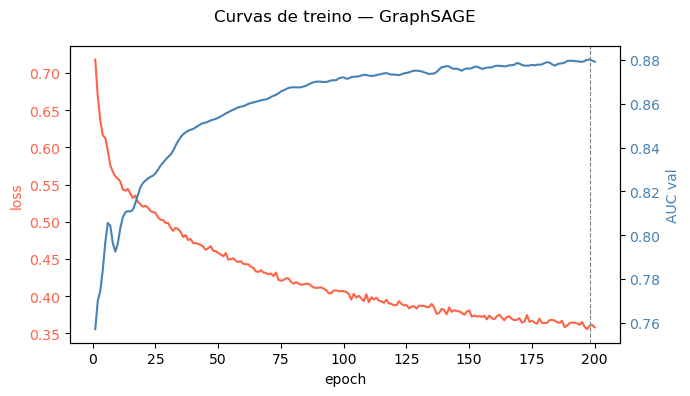

In [11]:
hist_df = pd.DataFrame(history)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(hist_df["epoch"], hist_df["loss"], color="tomato", label="loss treino")
ax1.set_xlabel("epoch")
ax1.set_ylabel("loss", color="tomato")
ax1.tick_params(axis="y", labelcolor="tomato")

ax2 = ax1.twinx()
ax2.plot(hist_df["epoch"], hist_df["val_auc"], color="steelblue", label="AUC val")
ax2.axvline(best_epoch, ls="--", color="gray", lw=0.8, label=f"best @ {best_epoch}")
ax2.set_ylabel("AUC val", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

fig.suptitle("Curvas de treino — GraphSAGE")
fig.tight_layout()
plt.show()

## 9. Avaliação em validação e teste

Métricas idêlnticas às fases anteriores (`03_ml_algorithms.ipynb`): AUC-ROC, Average Precision, F1 (threshold 0.5), Precision e Recall.

In [12]:
def metricas(y_true, proba):
    pred = (proba >= 0.5).astype(int)
    return {
        "AUC-ROC":   roc_auc_score(y_true, proba),
        "Avg Prec":  average_precision_score(y_true, proba),
        "F1":        f1_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall":    recall_score(y_true, pred, zero_division=0),
    }

val_proba  = score_split(val_pairs)
test_proba = score_split(test_pairs)

val_m  = metricas(val_y.cpu().numpy(),  val_proba)
test_m = metricas(test_y.cpu().numpy(), test_proba)

print("=== Validação ===")
for k, v in val_m.items():  print(f"  {k:<10} {v:.4f}")
print("\n=== Teste ===")
for k, v in test_m.items(): print(f"  {k:<10} {v:.4f}")

=== Validação ===
  AUC-ROC    0.8802
  Avg Prec   0.8811
  F1         0.8030
  Precision  0.7351
  Recall     0.8848

=== Teste ===
  AUC-ROC    0.8838
  Avg Prec   0.8878
  F1         0.8001
  Precision  0.7265
  Recall     0.8902


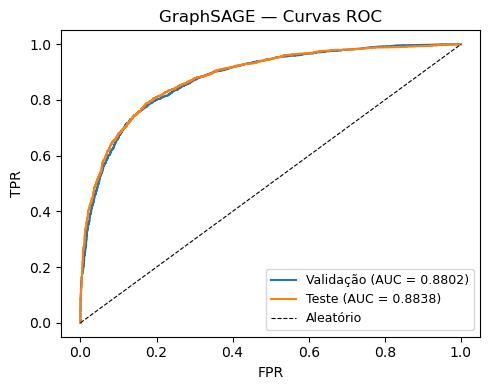

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
for proba, y_true, name in [
    (val_proba,  val_y.cpu().numpy(),  "Validação"),
    (test_proba, test_y.cpu().numpy(), "Teste"),
]:
    fpr, tpr, _ = roc_curve(y_true, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Aleatório")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("GraphSAGE — Curvas ROC")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 10. Persistência dos resultados

Salva uma linha por split em `data/results/gnn/results.csv`, com o mesmo schema de `data/results/results.csv` (gerado em `03_ml_algorithms.ipynb`), para consolidação futura.

In [14]:
method_name = "graphsage_areas" if INCLUDE_AREAS else "graphsage"

rows = [
    {"Método": method_name, "Split": "val",  **val_m},
    {"Método": method_name, "Split": "test", **test_m},
]
df_results = pd.DataFrame(rows)
for col in ["AUC-ROC", "Avg Prec", "F1", "Precision", "Recall"]:
    df_results[col] = df_results[col].map("{:.4f}".format)

out_path = RESULTS_DIR / "results.csv"
df_results.to_csv(out_path, index=False)
print(f"Salvo: {out_path}")
print(df_results.to_string(index=False))

Salvo: ../data/results/gnn/results.csv
   Método Split AUC-ROC Avg Prec     F1 Precision Recall
graphsage   val  0.8802   0.8811 0.8030    0.7351 0.8848
graphsage  test  0.8838   0.8878 0.8001    0.7265 0.8902


## 11. Comparação com fases anteriores

Junta os resultados de heurísticas + ML clássico (`data/results/results.csv`) com a linha do GraphSAGE e ordena por AUC-ROC em cada split. Esta tabela alimenta `08_resultados.md`.

In [15]:
prev_path = Path("../data/results/results.csv")
if prev_path.exists():
    df_prev = pd.read_csv(prev_path)
    df_all  = pd.concat([df_prev, df_results], ignore_index=True)
    df_all  = df_all.sort_values(["Split", "AUC-ROC"], ascending=[True, False]).reset_index(drop=True)
    print(df_all.to_string(index=False))
else:
    print("Sem resultados prévios em data/results/results.csv para comparar.")

          Método Split AUC-ROC Avg Prec      F1 Precision  Recall
       graphsage  test  0.8838   0.8878  0.8001    0.7265  0.8902
         xgboost  test  0.9597   0.9577  0.6914    0.9788  0.5345
   random_forest  test  0.9473   0.9496  0.7268     0.977  0.5786
            katz  test  0.9057   0.9111     0.0       0.0     0.0
     adamic_adar  test  0.7902   0.7894  0.5078    0.9881  0.3417
         jaccard  test  0.7902   0.7883  0.0049       1.0  0.0025
common_neighbors  test  0.7899   0.7871  0.7366    0.9775   0.591
       graphsage   val  0.8802   0.8811  0.8030    0.7351  0.8848
         xgboost   val  0.9622   0.9603   0.718     0.978  0.5672
   random_forest   val  0.9483   0.9501  0.7434    0.9713  0.6022
            katz   val  0.9026   0.9061     0.0       0.0     0.0
     adamic_adar   val  0.8021   0.8024  0.5379    0.9931  0.3689
common_neighbors   val  0.8015   0.7991  0.7537    0.9719  0.6155
         jaccard   val  0.8005   0.7978   0.007       1.0  0.0035


## 12. Comparação final — curvas ROC (teste)

Sobrepõe as curvas ROC no conjunto de teste para a melhor heurística (Katz), os dois modelos de ML supervisionado e o GraphSAGE — figura única que resume o desempenho de todas as famílias de métodos do projeto.

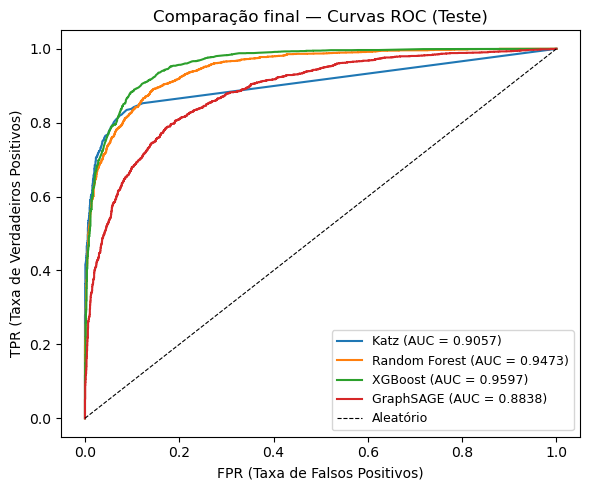

In [16]:
HEUR_DIR = Path("../data/results/heuristics")
ML_DIR   = Path("../data/results/ml")

fig, ax = plt.subplots(figsize=(6, 5))

# Heurística (melhor: Katz)
df_katz = pd.read_csv(HEUR_DIR / "katz_test.csv")
fpr, tpr, _ = roc_curve(df_katz["label"], df_katz["score"])
ax.plot(fpr, tpr, label=f"Katz (AUC = {roc_auc_score(df_katz['label'], df_katz['score']):.4f})")

# ML supervisionado
for nome, label in [("random_forest", "Random Forest"), ("xgboost", "XGBoost")]:
    df_ml = pd.read_csv(ML_DIR / f"{nome}_test.csv")
    fpr, tpr, _ = roc_curve(df_ml["label"], df_ml["score"])
    ax.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc_score(df_ml['label'], df_ml['score']):.4f})")

# GraphSAGE (já em memória)
fpr, tpr, _ = roc_curve(test_y.cpu().numpy(), test_proba)
ax.plot(fpr, tpr, label=f"GraphSAGE (AUC = {roc_auc_score(test_y.cpu().numpy(), test_proba):.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Aleatório")
ax.set_xlabel("FPR (Taxa de Falsos Positivos)")
ax.set_ylabel("TPR (Taxa de Verdadeiros Positivos)")
ax.set_title("Comparação final — Curvas ROC (Teste)")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

## 13. Comparação final — AUC-ROC por método

Gráfico de barras com o AUC-ROC (validação e teste) de todos os métodos avaliados no projeto, coloridos por estratégia (Heurística, ML, Rede Neural).

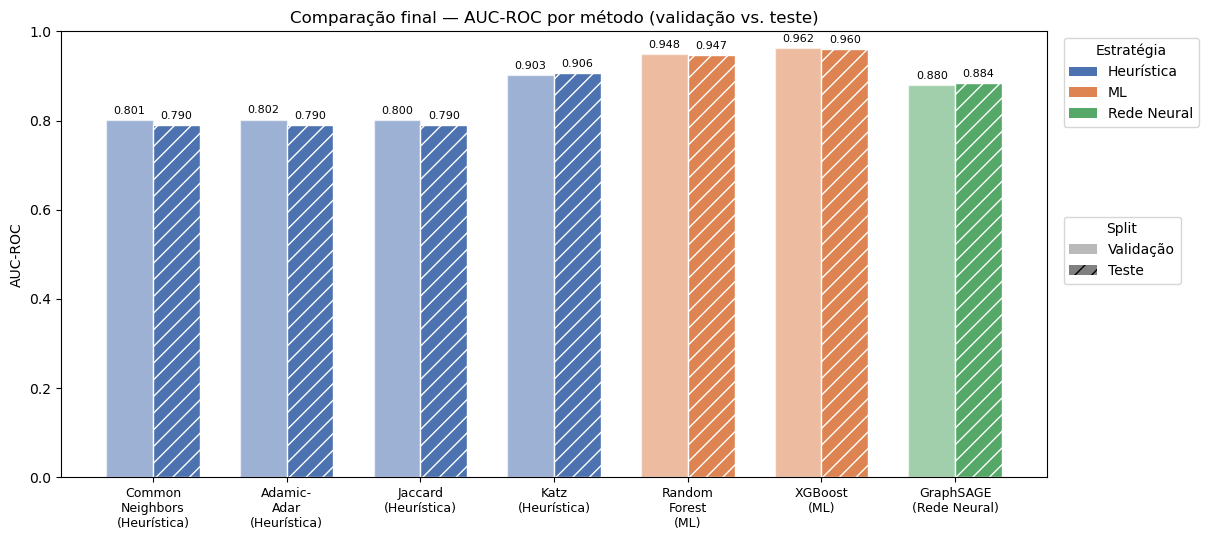

In [17]:
import matplotlib.patches as mpatches

# nome de exibição e categoria de cada método
method_info = {
    "common_neighbors": ("Common\nNeighbors", "Heurística"),
    "adamic_adar":      ("Adamic-\nAdar",      "Heurística"),
    "jaccard":          ("Jaccard",            "Heurística"),
    "katz":             ("Katz",               "Heurística"),
    "random_forest":    ("Random\nForest",     "ML"),
    "xgboost":          ("XGBoost",            "ML"),
    "graphsage":        ("GraphSAGE",          "Rede Neural"),
}

category_colors = {
    "Heurística":  "#4C72B0",
    "ML":          "#DD8452",
    "Rede Neural": "#55A868",
}

df_plot = df_all.copy()
df_plot["AUC-ROC"] = df_plot["AUC-ROC"].astype(float)

metodos = list(method_info.keys())

fig, ax = plt.subplots(figsize=(12, 5.5))
largura = 0.35
x = range(len(metodos))

for i, (split, hatch, alpha) in enumerate([("val", "", 0.55), ("test", "//", 1.0)]):
    valores = [
        df_plot.loc[(df_plot["Método"] == m) & (df_plot["Split"] == split), "AUC-ROC"].values[0]
        for m in metodos
    ]
    cores = [category_colors[method_info[m][1]] for m in metodos]
    offset = (i - 0.5) * largura
    bars = ax.bar(
        [xi + offset for xi in x], valores, largura,
        color=cores, alpha=alpha, hatch=hatch, edgecolor="white",
    )
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

ax.set_xticks(list(x))
ax.set_xticklabels(
    [f"{method_info[m][0]}\n({method_info[m][1]})" for m in metodos],
    fontsize=9,
)
ax.set_ylim(0, 1)
ax.set_ylabel("AUC-ROC")
ax.set_title("Comparação final — AUC-ROC por método (validação vs. teste)")

# legendas separadas: estratégia (cor) e split (alpha/hatch)
cat_patches = [mpatches.Patch(facecolor=c, label=cat) for cat, c in category_colors.items()]
split_patches = [
    mpatches.Patch(facecolor="gray", alpha=0.55, hatch="",   label="Validação"),
    mpatches.Patch(facecolor="gray", alpha=1.0,  hatch="//", label="Teste"),
]
legend1 = ax.legend(handles=cat_patches, title="Estratégia", loc="upper left", bbox_to_anchor=(1.01, 1))
ax.add_artist(legend1)
ax.legend(handles=split_patches, title="Split", loc="upper left", bbox_to_anchor=(1.01, 0.6))

plt.tight_layout()
plt.show()